# Corpus EDA — arXiv ingestion

Exploratory analysis of the parquet produced by `src.ingestion.pipeline.run_pipeline`.

Four questions this notebook answers:

1. **What did we actually ingest?** Counts, date range, category mix.
2. **Did ingestion work?** Download/extraction failure rates, and silent failures that are marked `complete` but contain nothing.
3. **Is the text chunkable?** Do the markdown headings from `pymupdf4llm` give us real section boundaries, and how much of each paper is References?
4. **How big is the index going to be?** Rough chunk and token counts.

Run top to bottom. Every section prints numbers you can paste straight into the data-preparation writeup.

## 0. Setup

In [1]:
import sys, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")  # so src is importable
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 110

# adjust if the notebook does not live in notebooks/
DATASET_PATH = Path("../data/papers.parquet")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATASET_PATH)
print(f"{len(df):,} rows, {df.shape[1]} columns")
print(f"parquet size on disk: {DATASET_PATH.stat().st_size / 1e6:.1f} MB")
df.dtypes

160 rows, 15 columns
parquet size on disk: 6.2 MB


arxiv_id                             str
title                                str
abstract                             str
authors                           object
primary_category                     str
categories                        object
published            datetime64[us, UTC]
updated              datetime64[us, UTC]
pdf_url                              str
abs_url                              str
pdf_path                             str
download_status                      str
extracted_text                       str
extraction_status                    str
ingestion_status                     str
dtype: object

## 1. Corpus overview

Basic shape. If `published` spans only a couple of days, the corpus is a thin
recency slice rather than a representative sample of cs.AI — worth stating as a
limitation.

In [2]:
df["published"] = pd.to_datetime(df["published"], utc=True)
df["updated"] = pd.to_datetime(df["updated"], utc=True)

print("date range :", df["published"].min().date(), "->", df["published"].max().date())
print("span       :", (df["published"].max() - df["published"].min()).days, "days")
print("unique ids :", df["arxiv_id"].nunique())

# strip the version suffix to spot the same paper ingested twice
df["base_id"] = df["arxiv_id"].str.replace(r"v\d+$", "", regex=True)
dupes = df["base_id"].duplicated().sum()
print("duplicate base ids (same paper, different version):", dupes)

date range : 2026-09-22 -> 2026-09-25
span       : 3 days
unique ids : 160
duplicate base ids (same paper, different version): 0


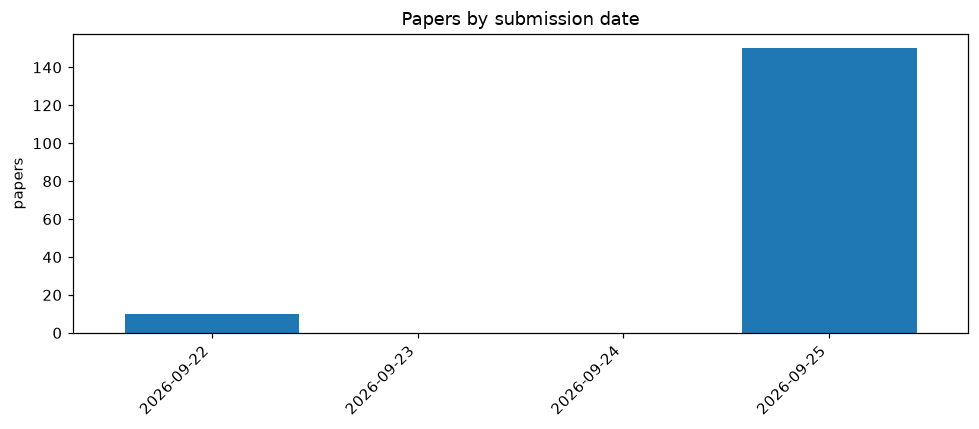

In [3]:
fig, ax = plt.subplots()
df.set_index("published").resample("D").size().plot(kind="bar", ax=ax, width=0.85)
ax.set_title("Papers by submission date")
ax.set_xlabel(""); ax.set_ylabel("papers")
ax.set_xticklabels([t.get_text()[:10] for t in ax.get_xticklabels()], rotation=45, ha="right")
plt.tight_layout(); plt.savefig(FIG_DIR / "papers_by_date.png"); plt.show()

## 2. Ingestion health

The three status columns tell you where papers died. `ingestion_status == "complete"`
is what `get_ingested_ids` uses to skip on rerun, so anything not complete will be
retried next time the pipeline runs.

In [4]:
for col in ["download_status", "extraction_status", "ingestion_status"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string())
    print()

complete_rate = (df["ingestion_status"] == "complete").mean()
print(f"end-to-end success rate: {complete_rate:.1%}")

--- download_status ---
download_status
downloaded    160

--- extraction_status ---
extraction_status
extracted    160

--- ingestion_status ---
ingestion_status
complete    160

end-to-end success rate: 100.0%


In [5]:
# where exactly do failures happen?
pd.crosstab(df["download_status"], df["extraction_status"], margins=True)

extraction_status,extracted,All
download_status,,
downloaded,160,160
All,160,160


In [6]:
# inspect the failures individually — with a small corpus you can eyeball every one
failed = df[df["ingestion_status"] != "complete"]
if len(failed):
    display(failed[["arxiv_id", "title", "download_status", "extraction_status", "pdf_url"]])
else:
    print("no failures")

no failures


## 3. Text length and silent failures

This is the section that catches the bug the status columns miss. `extract_all`
marks a paper `extracted` whenever `to_markdown` returns anything non-`None`. A
scanned or image-only PDF returns a near-empty string, so it sails through as
`complete` with almost no text in it.

In [7]:
df["char_count"] = df["extracted_text"].fillna("").str.len()
df["word_count"] = df["extracted_text"].fillna("").str.split().str.len()
# ~4 chars per token is the usual rule of thumb for English prose
df["est_tokens"] = (df["char_count"] / 4).round().astype(int)

print(df[["char_count", "word_count", "est_tokens"]].describe().round(0).to_string())

       char_count  word_count  est_tokens
count       160.0       160.0       160.0
mean      71614.0      9594.0     17904.0
std       37390.0      4712.0      9347.0
min       14143.0      1929.0      3536.0
25%       43652.0      5864.0     10913.0
50%       63532.0      8877.0     15884.0
75%       91284.0     12739.0     22821.0
max      256811.0     31084.0     64203.0


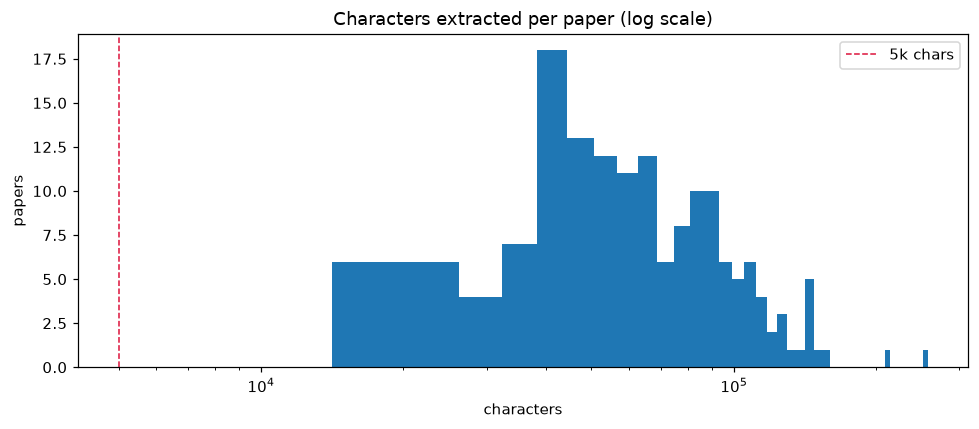

In [8]:
extracted = df[df["extraction_status"] == "extracted"]

fig, ax = plt.subplots()
ax.hist(extracted["char_count"].clip(lower=1), bins=40)
ax.set_xscale("log")
ax.axvline(5000, color="crimson", ls="--", lw=1, label="5k chars")
ax.set_title("Characters extracted per paper (log scale)")
ax.set_xlabel("characters"); ax.set_ylabel("papers"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "char_count_dist.png"); plt.show()

In [9]:
# a real cs.AI paper is tens of thousands of characters.
# anything under ~5k is almost certainly a broken extraction.
SUSPICIOUS = 5_000

suspect = extracted[extracted["char_count"] < SUSPICIOUS].sort_values("char_count")
print(f"{len(suspect)} of {len(extracted)} 'extracted' papers are under {SUSPICIOUS:,} chars "
      f"({len(suspect)/max(len(extracted),1):.1%})")

suspect[["arxiv_id", "title", "char_count", "ingestion_status"]].head(20)

0 of 160 'extracted' papers are under 5,000 chars (0.0%)


,arxiv_id,title,char_count,ingestion_status


In [10]:
# read the start of the shortest one — usually makes the cause obvious
# (no text layer, a withdrawn paper, or a PDF that is one big image)
if len(suspect):
    worst = suspect.iloc[0]
    print(worst["arxiv_id"], "|", worst["title"])
    print(worst["pdf_url"])
    print("-" * 70)
    print((worst["extracted_text"] or "")[:1500])
else:
    print("nothing suspiciously short")

nothing suspiciously short


## 4. Structure — will heading-based chunking work?

`pymupdf4llm` emits markdown, so section headings should come through as `#`/`##`
lines. If they do, you can chunk on section boundaries instead of blind fixed-size
windows, and carry a real section label into every citation. If most papers have
zero headings, that plan doesn't work and you need a different splitter.

papers with >=1 markdown heading: 100.0%
median headings per paper       : 31


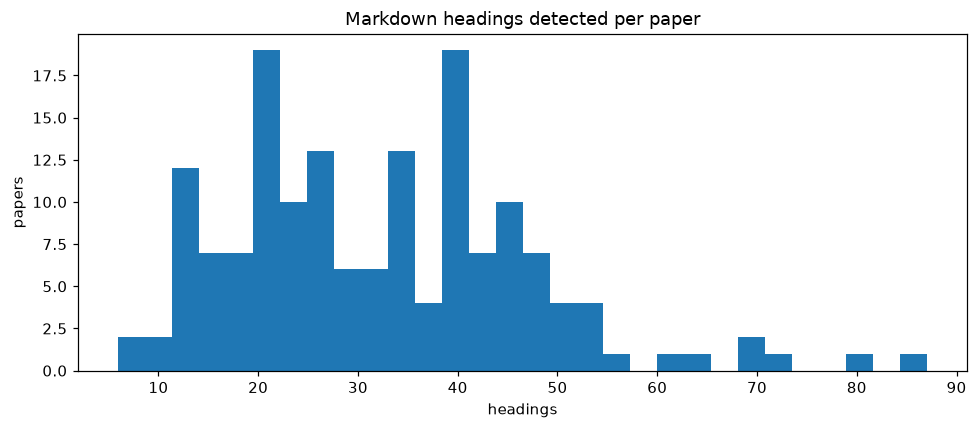

In [11]:
HEADING_RE = re.compile(r"^(#{1,6})\s+(.+?)\s*$", re.M)
REF_RE = re.compile(r"^#{1,6}\s*\**\s*(?:\d+\.?\s*)?(references|bibliography)\b", re.I | re.M)

def heading_texts(text):
    if not text:
        return []
    return [h[1] for h in HEADING_RE.findall(text)]

df["n_headings"] = df["extracted_text"].apply(lambda t: len(heading_texts(t)))
df["has_headings"] = df["n_headings"] > 0

print(f"papers with >=1 markdown heading: {df.loc[extracted.index, 'has_headings'].mean():.1%}")
print(f"median headings per paper       : {df.loc[extracted.index, 'n_headings'].median():.0f}")

fig, ax = plt.subplots()
ax.hist(df.loc[extracted.index, "n_headings"], bins=30)
ax.set_title("Markdown headings detected per paper")
ax.set_xlabel("headings"); ax.set_ylabel("papers")
plt.tight_layout(); plt.savefig(FIG_DIR / "headings_per_paper.png"); plt.show()

In [12]:
# what do the headings actually look like? sanity-check that they are section
# titles and not page artifacts or figure captions
from collections import Counter

all_heads = Counter()
for t in extracted["extracted_text"]:
    for h in heading_texts(t):
        all_heads[re.sub(r"^[\d\.\s]+", "", h).strip().lower()[:40]] += 1

pd.DataFrame(all_heads.most_common(25), columns=["heading", "count"])

,heading,count
0,**references**,103
1,**abstract**,93
2,**1 introduction**,75
3,references,50
4,**2 related work**,36
5,introduction,31
6,abstract,27
7,related work,24
8,conclusion,19
9,i. introduction,18


In [13]:
# how much of each paper is the References section?
def ref_tail_fraction(text):
    if not text:
        return np.nan
    m = REF_RE.search(text)
    if not m:
        return np.nan
    return (len(text) - m.start()) / len(text)

df["ref_tail_frac"] = df["extracted_text"].apply(ref_tail_fraction)

found = df["ref_tail_frac"].notna()
print(f"References heading found in {found.loc[extracted.index].mean():.1%} of extracted papers")
print(f"median share of the document after it: {df['ref_tail_frac'].median():.1%}")
print(f"characters recoverable by dropping references: "
      f"{(df['char_count'] * df['ref_tail_frac'].fillna(0)).sum():,.0f}")

References heading found in 99.4% of extracted papers
median share of the document after it: 37.4%
characters recoverable by dropping references: 5,182,627


In [14]:
# leftover cleaning artifacts
df["n_picture_omitted"] = df["extracted_text"].fillna("").str.count(r"\[Picture Omitted\]")
print("papers containing [Picture Omitted]:", (df["n_picture_omitted"] > 0).sum())
print("total blocks replaced:", df["n_picture_omitted"].sum())

# did any picture blocks survive the regex?
leftover = df["extracted_text"].fillna("").str.contains("Start of picture text").sum()
print("papers with unreplaced picture blocks:", leftover)

papers containing [Picture Omitted]: 122
total blocks replaced: 611
papers with unreplaced picture blocks: 0


## 5. Abstracts — the Tier 1 corpus

Abstracts need no PDF parsing and are already clean, so they are the fastest path
to a working baseline retriever. Confirm they are all present and sanely sized
before building on them.

missing/empty abstracts: 0
count     160.0
mean     1422.0
std       281.0
min       802.0
25%      1233.0
50%      1431.0
75%      1652.0
max      1919.0


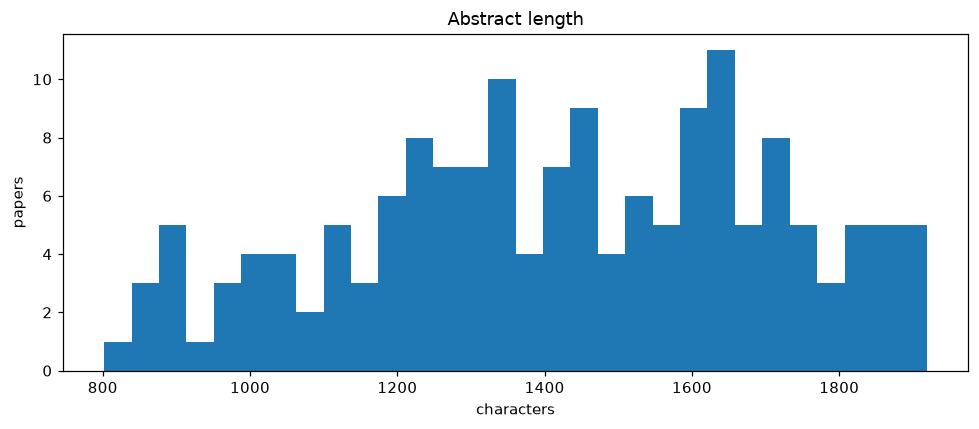

In [15]:
df["abstract_chars"] = df["abstract"].fillna("").str.len()

print("missing/empty abstracts:", (df["abstract_chars"] == 0).sum())
print(df["abstract_chars"].describe().round(0).to_string())

fig, ax = plt.subplots()
ax.hist(df["abstract_chars"], bins=30)
ax.set_title("Abstract length")
ax.set_xlabel("characters"); ax.set_ylabel("papers")
plt.tight_layout(); plt.savefig(FIG_DIR / "abstract_length.png"); plt.show()

## 6. Category mix

`primary_category` is what the paper was filed under; `categories` includes
cross-lists. A cs.AI query pulls in a lot of cs.LG and cs.CL, which is fine, but
you should know the mix so you can describe corpus coverage to stakeholders.

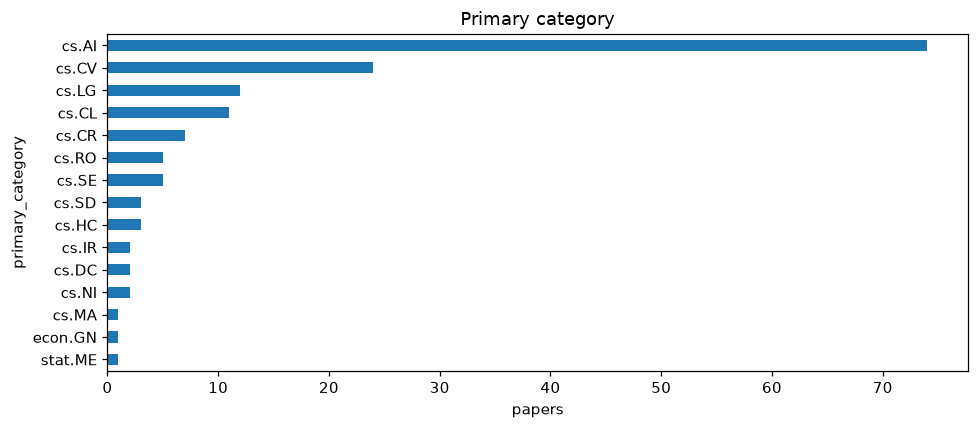

mean cross-lists per paper: 1.99


cs.AI      160
cs.LG       32
cs.CV       30
cs.CL       21
cs.CR       10
cs.SE        9
cs.RO        5
cs.DC        5
cs.HC        4
cs.IR        3
stat.ME      3
cs.IT        3
cs.SD        3
eess.AS      3
cs.MA        2
Name: count, dtype: int64

In [16]:
fig, ax = plt.subplots()
df["primary_category"].value_counts().head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Primary category")
ax.set_xlabel("papers")
plt.tight_layout(); plt.savefig(FIG_DIR / "primary_categories.png"); plt.show()

df["n_categories"] = df["categories"].apply(len)
print("mean cross-lists per paper:", round(df["n_categories"].mean(), 2))

all_cats = pd.Series([c for cats in df["categories"] for c in cats])
all_cats.value_counts().head(15)

## 7. Index size projection

Rough sizing for the embedding step, so you know whether the corpus you plan to
build is affordable before you build it.

In [17]:
CHUNK_TOKENS = 800
OVERLAP = 0.15

usable_tokens = (df["est_tokens"] * (1 - df["ref_tail_frac"].fillna(0))).sum()
est_chunks = usable_tokens / (CHUNK_TOKENS * (1 - OVERLAP))

print(f"papers                       : {len(df):,}")
print(f"estimated tokens (all text)  : {df['est_tokens'].sum():,}")
print(f"estimated tokens (no refs)   : {usable_tokens:,.0f}")
print(f"estimated chunks @ {CHUNK_TOKENS} tokens: {est_chunks:,.0f}")
print(f"chunks per paper             : {est_chunks / max(len(df), 1):.1f}")
print()
for target in [1_000, 5_000, 10_000]:
    scale = target / max(len(df), 1)
    print(f"  at {target:,} papers -> ~{est_chunks * scale:,.0f} chunks")

papers                       : 160
estimated tokens (all text)  : 2,864,564
estimated tokens (no refs)   : 1,568,907
estimated chunks @ 800 tokens: 2,307
chunks per paper             : 14.4

  at 1,000 papers -> ~14,420 chunks
  at 5,000 papers -> ~72,101 chunks
  at 10,000 papers -> ~144,201 chunks


## 8. Save the per-paper stats

Writes a small table (no full text) that later notebooks and the writeup can load
cheaply.

In [18]:
stats_cols = [
    "arxiv_id", "base_id", "title", "primary_category", "published",
    "download_status", "extraction_status", "ingestion_status",
    "char_count", "word_count", "est_tokens", "abstract_chars",
    "n_headings", "ref_tail_frac", "n_picture_omitted",
]
stats = df[stats_cols].copy()

out = Path("../data/paper_stats.parquet")
stats.to_parquet(out, index=False)
print(f"wrote {out}  ({out.stat().st_size / 1e3:.0f} KB, {len(stats):,} rows)")
stats.head()

wrote ../data/paper_stats.parquet  (28 KB, 160 rows)


,arxiv_id,base_id,title,primary_category,published,download_status,extraction_status,ingestion_status,char_count,word_count,est_tokens,abstract_chars,n_headings,ref_tail_frac,n_picture_omitted
0,2609.26780v1,2609.26780,SpeakerMem-R1: Speaker-Centered Dual-Track Memory for Multi-Party Dialogue,cs.CL,2026-09-22 17:56:12+00:00,downloaded,extracted,complete,126274,16437,31568,1902,39,0.747303,6
1,2609.26779v1,2609.26779,CliffCompaction: Cost-Efficient Compaction for Long-Horizon Coding Agents,cs.AI,2026-09-22 17:55:59+00:00,downloaded,extracted,complete,84471,11318,21118,1573,31,0.456109,7
2,2609.26777v1,2609.26777,SWE-Serve: Benchmarking Agentic Engineering For Production Inference Serving,cs.AI,2026-09-22 17:54:59+00:00,downloaded,extracted,complete,108392,13555,27098,1864,45,0.688344,16
3,2609.26761v1,2609.26761,A2M: Trace-Optimized Agent Hijacking in the MCP Ecosystem,cs.CR,2026-09-22 17:41:34+00:00,downloaded,extracted,complete,67528,9474,16882,1189,65,0.509789,3
4,2609.26760v1,2609.26760,"Grow the Harness, Not the Context: From Strategy-Free Scaffolds to Reusable ...",cs.AI,2026-09-22 17:40:45+00:00,downloaded,extracted,complete,53328,7149,13332,1705,28,0.269671,6


## 9. Findings

Corpus: the 160 newest cs.AI submissions (2026-09-22 → 2026-09-25), ingested and run on 2026-09-28.
The full data preparation write-up is `src/preprocessing/README.md`.

| question | number | what we do about it |
|---|---|---|
| papers ingested | 160 (74 primary cs.AI, rest cross-listed: cs.CV 24, cs.LG 12, cs.CL 11) | fine for a baseline, grow to ~1k before evaluation |
| end-to-end success rate | 100% (0 download / extraction failures) | keep the `ingestion_status` checks, no action now |
| extractions under 5k chars | 0 | `quality.py` still flags `short_body` so silent failures are caught as the corpus grows |
| papers with usable headings | 100% (median 31 headings) | chunk on headings, fixed size windows inside long sections |
| median share that is References (+ appendix after it) | 37.4% of each paper; references alone ≈14% and appendix ≈32% of cleaned text | drop both from `body_text`, keep them in `sections` |
| running head / page number lines | 3,526 removed (~22 per paper) | `boilerplate.py` removes them |
| estimated chunks at current size | ~2.1k chunks from ~1.45M body tokens (800 tokens, 15% overlap) | cheap to embed; ~13k chunks at 1k papers |

**Decisions this EDA supports**

- Chunking strategy: **heading-based**. Every paper has markdown headings, and `sections` carries a `section_type` for citations (§4).
- Minimum-character check: **added** as the `short_body` flag in `src/preprocessing/quality.py`, not in `extract_all`, so raw data stays untouched (§3).
- Drop References before indexing: **yes**, along with appendix, front matter, acknowledgments and back matter. `body_text` keeps 51% of the raw characters (§4, §10).
- Target corpus size for the baseline: 160 papers is enough to build and debug retrieval. Grow to ~1k papers across a wider date range before running the evaluation.

**Known limitations to carry into the final report**

- The corpus is a 3-day recency slice of cs.AI, not a representative sample. Topic coverage is skewed to whatever was submitted that week.
- Math and tables come from PDF layout, not LaTeX source, so equations are flattened unicode and some tables lose alignment.
- Section typing is keyword + position based. ~9% of text is typed `other` (creative headings), and journal layouts with Methods after References lose that section to `appendix`.
- No OCR: scanned PDFs would be flagged and excluded, not recovered.


## 10. Preprocessing impact

What `src.preprocessing` did to the corpus. Run the preprocessing step first
(`python -m src.preprocessing.cli` from the project root). It writes
`data/papers_clean.parquet` and `data/preprocess_report.json`. The approach is
documented in `src/preprocessing/README.md`.

In [19]:
import json

clean = pd.read_parquet("../data/papers_clean.parquet")
report = json.load(open("../data/preprocess_report.json"))

print(f"papers in / out          : {report['papers_in']} / {report['papers_out']} "
      f"({report['duplicate_versions_dropped']} duplicate versions dropped)")
print(f"usable for indexing      : {report['usable_papers']} ({report['usable_rate']:.1%})")
print(f"artifact lines removed   : {report['artifact_lines_removed']:,}")
print(f"references found         : {report['references_found_rate']:.1%}")
print(f"papers with an appendix  : {report['appendix_rate']:.1%}")
print(f"raw chars -> body chars  : {report['raw_chars_total']:,} -> {report['body_chars_total']:,} "
      f"({report['body_chars_total'] / report['raw_chars_total']:.0%} kept)")
print(f"median body tokens/paper : {report['body_tokens_median']:,}")
print(f"total body tokens (usable): {report['body_tokens_total_usable']:,}")

papers in / out          : 160 / 160 (0 duplicate versions dropped)
usable for indexing      : 160 (100.0%)
artifact lines removed   : 3,526
references found         : 99.4%
papers with an appendix  : 66.9%
raw chars -> body chars  : 11,458,261 -> 5,786,284 (50% kept)
median body tokens/paper : 8,215
total body tokens (usable): 1,446,573


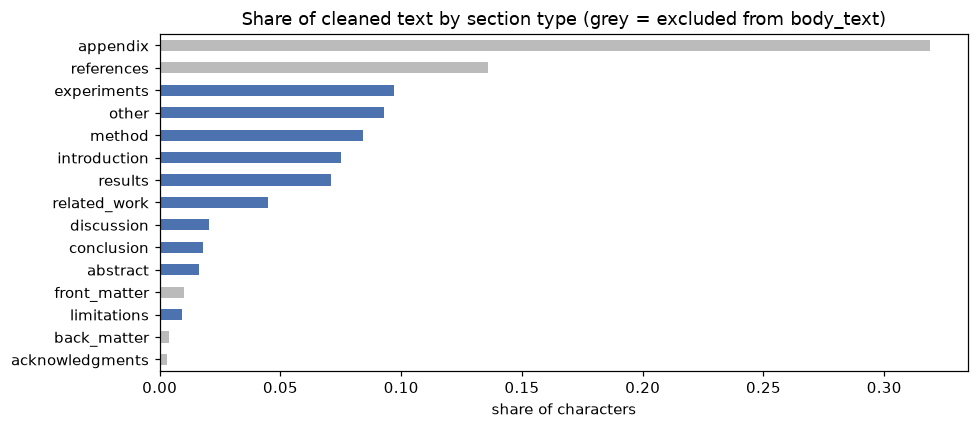

In [20]:
# how much of each paper survives into body_text, and why the rest was dropped
from src.preprocessing.sections import EXCLUDED_FROM_BODY
drop_types = EXCLUDED_FROM_BODY

def chars_by_type(sections):
    out = {}
    for s in sections:
        out[s["section_type"]] = out.get(s["section_type"], 0) + s["char_count"]
    return out

by_type = pd.DataFrame([chars_by_type(s) for s in clean["sections"]]).fillna(0)
share = (by_type.sum() / by_type.sum().sum()).sort_values()

fig, ax = plt.subplots()
colors = ["#bbbbbb" if t in drop_types else "#4c72b0" for t in share.index]
share.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Share of cleaned text by section type (grey = excluded from body_text)")
ax.set_xlabel("share of characters")
plt.tight_layout(); plt.savefig(FIG_DIR / "section_type_share.png"); plt.show()

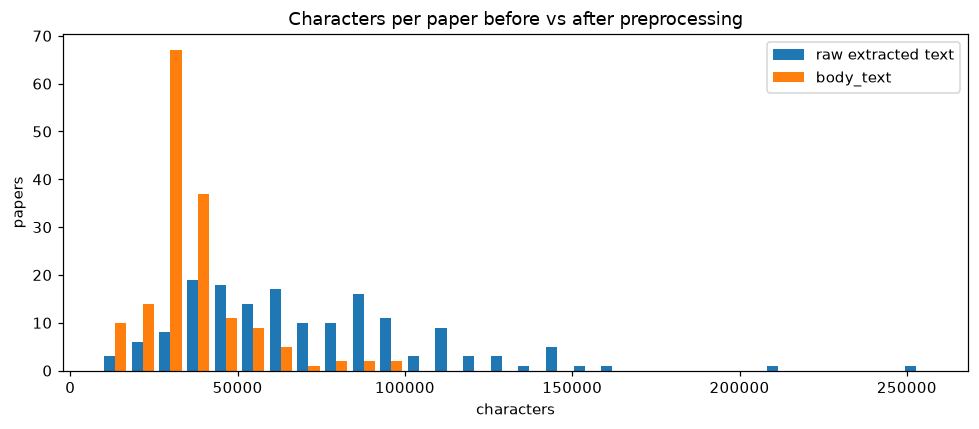

In [21]:
fig, ax = plt.subplots()
ax.hist([clean["raw_char_count"], clean["body_char_count"]], bins=30, label=["raw extracted text", "body_text"])
ax.set_title("Characters per paper before vs after preprocessing")
ax.set_xlabel("characters"); ax.set_ylabel("papers"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "raw_vs_body_chars.png"); plt.show()

In [22]:
# quality issues: blocking ones make is_usable False, the rest are informational
pd.Series(report["quality_issues"], name="papers", dtype=int).to_frame()

,papers
no_references_found,1


In [23]:
# every unusable paper with its reasons, eyeball these
pd.DataFrame(report["unusable_papers"])

""


In [24]:
# which running heads/footers got stripped across the corpus
from src.preprocessing.boilerplate import artifact_counts
from src.preprocessing.normalize import normalize_text

raw_df = pd.read_parquet(DATASET_PATH, columns=["extracted_text"])
heads = artifact_counts(normalize_text(t) for t in raw_df["extracted_text"])
pd.DataFrame(heads.most_common(20), columns=["running head (normalized)", "papers"])

,running head (normalized),papers
0,preprint,8
1,preprint.,3
2,m. m. shahriar et al.: preprint submitted to elsevier,2
3,running title for header,2
4,"grow the harness, not the context",1
5,butoi et al.,1
6,flexray,1
7,metrics failure in llm code vulnerability repair,1
8,o. nepal et al.,1
9,stewart et al.,1


In [25]:
# before / after on one paper
sample = clean.sort_values("n_artifact_lines_removed").iloc[-1]
raw_text = df.set_index("arxiv_id").loc[sample["arxiv_id"], "extracted_text"]
print(sample["arxiv_id"], "|", sample["title"])
print("=" * 30, "RAW", "=" * 30)
print(raw_text[:1500])
print("=" * 30, "BODY_TEXT", "=" * 30)
print(sample["body_text"][:1500])

2609.31013v1 | Same Text, Different Numbers: The Divergence of LLM-Based Measures
============================== RAW ==============================
## **Same Text, Different Numbers: The Divergence of LLM-Based Measures**<sup>∗</sup> 

Hamid Boustanifar<sup>†</sup> Sasan Mansouri<sup>‡</sup> 

#### **ABSTRACT** 

Researchers increasingly use generative large language models (LLMs) to convert corporate text into empirical variables. We examine the extent to which LLM-based textual measures are invariant to model choice using thirteen measures, including sentiment, management clarity, uncertainty, answer specificity, and climate and political risk. Seven LLMs from different providers score earnings call transcripts of S\&P 500 companies on these constructs. Cross-model rank correlations average only 0.52, and transcript-level differences common across providers account for only 34\% of total score variation. Cross-model disagreement does not predict subsequent analyst or market disagreem

In [26]:
# section outline of one paper, to check the section typing by eye
pd.DataFrame(list(sample["sections"]))[["idx", "level", "number", "heading", "section_type", "char_count"]]

,idx,level,number,heading,section_type,char_count
0,0,2,,"Same Text, Different Numbers: The Divergence of LLM-Based Measures",front_matter,32
1,1,4,,ABSTRACT,abstract,3984
2,2,2,1,Introduction,introduction,13634
3,3,2,2,Related Literature,related_work,6308
4,4,2,3,Data,other,0
5,5,3,3.1,Sample,other,556
6,6,3,3.2,LLM-based textual measures,other,12673
7,7,3,3.3,Traditional textual measures,other,2514
8,8,3,3.4,Financial data and outcomes,other,894
9,9,2,4,Empirical analysis,results,1229
